# 300 - PDAC CyTOF PAE K-Sweep (3 Seeds)

This notebook runs and summarizes a **probabilistic archetypal autoencoder (PAE)** K sweep on:

- `data/PDAC_normalized.h5ad`

using:

- seeds: `42, 123, 456`
- K values from `PDAC/configs/pae_k_sweep.yaml`

Flow:
1. Load sweep config and inspect dataset metadata.
2. Run sweep (`PDAC/run_pae_k_sweep.py`).
3. Summarize outputs and recommend K.
4. Inspect archetype marker profiles for recommended K.


In [20]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import anndata as ad

REPO_ROOT = Path('..').resolve()
CONFIG_PATH = REPO_ROOT / 'PDAC' / 'configs' / 'pae_k_sweep.yaml'
RUNNER_PATH = REPO_ROOT / 'PDAC' / 'run_pae_k_sweep.py'

assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'
assert RUNNER_PATH.exists(), f'Missing runner: {RUNNER_PATH}'

print('Repo root :', REPO_ROOT)
print('Config    :', CONFIG_PATH)
print('Runner    :', RUNNER_PATH)


Repo root : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv
Config    : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/PDAC/configs/pae_k_sweep.yaml
Runner    : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/PDAC/run_pae_k_sweep.py


## Step 1 - Load Config and Define Paths


In [21]:
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)


def _resolve_path(p: str | None) -> Path | None:
    if p is None:
        return None
    pp = Path(p).expanduser()
    if not pp.is_absolute():
        pp = REPO_ROOT / pp
    return pp

DATASET_H5AD = _resolve_path(cfg['dataset']['input_path'])
OUTPUT_DIR = _resolve_path(cfg['output_dir'])
SEED_LEVEL_CSV = OUTPUT_DIR / 'tables' / 'pae_k_sweep_seed_level.csv'
AGG_CSV = OUTPUT_DIR / 'tables' / 'pae_k_sweep_k_aggregate.csv'
KSEL_CSV = OUTPUT_DIR / 'tables' / 'pae_k_selection_summary.csv'

print('Dataset h5ad:', DATASET_H5AD)
print('Output dir  :', OUTPUT_DIR)
print('K values    :', cfg.get('sweeps', {}).get('k_values', []))
print('Seeds       :', cfg.get('seeds', []))
print('PAE cfg keys:', sorted(cfg.get('methods', {}).get('probabilistic_archetypal_ae', {}).keys()))


Dataset h5ad: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/PDAC_normalized.h5ad
Output dir  : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDAC/pae_k_sweep
K values    : [7, 8, 9, 10]
Seeds       : [42, 123, 456]
PAE cfg keys: ['batch_size', 'device', 'diversity_reg_weight', 'dropout', 'entropy_reg_weight', 'grad_clip', 'hidden_dims', 'lr', 'max_epochs', 'patience', 'variance_reg_weight', 'weight_decay']


## Step 2 - Quick Dataset Check


In [22]:
EXCLUDED_TRAIN_MARKERS = ['H3', 'H3.3', 'H4','CD45']
adata = ad.read_h5ad(DATASET_H5AD)
train_markers = [m for m in adata.var_names.tolist() if m not in EXCLUDED_TRAIN_MARKERS]
print(f'h5ad loaded: {adata.n_obs:,} cells x {adata.n_vars:,} markers')
print(f'training markers after excluding normalization controls: {len(train_markers):,}')
print('excluded training markers:', EXCLUDED_TRAIN_MARKERS)

obs = adata.obs.copy()
needed_cols = [c for c in ['Treatment', 'sample'] if c in obs.columns]
if len(needed_cols) == 2:
    combos = (
        obs[['Treatment', 'sample']]
        .astype(str)
        .drop_duplicates()
        .sort_values(['Treatment', 'sample'])
        .reset_index(drop=True)
    )
    print('Unique Treatment x sample combinations:')
    display(combos)

    counts = (
        obs[['Treatment', 'sample']]
        .astype(str)
        .groupby(['Treatment', 'sample'])
        .size()
        .reset_index(name='n_cells')
        .sort_values(['Treatment', 'sample'])
    )
    display(counts)
else:
    print('Treatment/sample columns missing in obs. Available:', list(obs.columns))


h5ad loaded: 51,136 cells x 41 markers
training markers after excluding normalization controls: 37
excluded training markers: ['H3', 'H3.3', 'H4', 'CD45']
Unique Treatment x sample combinations:


,Treatment,sample
0,Treated,68
1,Treated,71
2,Untreated,66


,Treatment,sample,n_cells
0,Treated,68,20437
1,Treated,71,6329
2,Untreated,66,24370


## Step 3 - Run K Sweep


In [23]:
RUN_SWEEP = True  # set False to skip execution and only load existing outputs

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from PDAC.run_pae_k_sweep import run_pae_k_sweep

if RUN_SWEEP:
    # Run in-process so tqdm renders as an updating notebook progress bar.
    result = run_pae_k_sweep(CONFIG_PATH)
    print('Sweep completed.')
    print('Output directory:', result['output_dir'])
    print('Recommended K  :', result['recommended_k'])
else:
    print('Sweep skipped (RUN_SWEEP=False).')


MPS/GPU benchmark runs:   0%|                                                                                                     | 0/12 [00:00<?, ?run/s]

[core-stage] running 12 MPS/GPU+serial jobs
[core-run 1/12] START method=probabilistic_archetypal_ae dim=7 seed=42 device=auto


probabilistic_archetypal_ae dim=7 seed=42:   0%|          | 0/3000 [00:00<?, ?epoch/s]

[core-run 1/12] DONE  method=probabilistic_archetypal_ae dim=7 seed=42 val_mse=0.523210 test_mse=0.526684 elapsed=48.4s
[accel-stage 1/12] method=probabilistic_archetypal_ae dim=7 seed=42


MPS/GPU benchmark runs:   8%|███▍                                     | 1/12 [00:48<08:52, 48.43s/run, method=probabilistic_archetypal_ae, dim=7, seed=42]

...

[core-run 12/12] START method=probabilistic_archetypal_ae dim=10 seed=456 device=auto


probabilistic_archetypal_ae dim=10 seed=456:   0%|          | 0/3000 [00:00<?, ?epoch/s]

[core-run 12/12] DONE  method=probabilistic_archetypal_ae dim=10 seed=456 val_mse=0.442531 test_mse=0.447517 elapsed=47.8s
[accel-stage 12/12] method=probabilistic_archetypal_ae dim=10 seed=456


MPS/GPU benchmark runs: 100%|██████████████████████████████████████| 12/12 [09:32<00:00, 47.71s/run, method=probabilistic_archetypal_ae, dim=10, seed=456]


Sweep completed.
Output directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDAC/pae_k_sweep
Recommended K  : 10


## Step 4 - Load Sweep Outputs


In [24]:
assert SEED_LEVEL_CSV.exists(), f'Missing: {SEED_LEVEL_CSV}'
assert AGG_CSV.exists(), f'Missing: {AGG_CSV}'
assert KSEL_CSV.exists(), f'Missing: {KSEL_CSV}'

seed_df = pd.read_csv(SEED_LEVEL_CSV)
agg_df = pd.read_csv(AGG_CSV)
ksel_df = pd.read_csv(KSEL_CSV)

print('Seed-level rows:', len(seed_df))
print('K aggregate rows:', len(agg_df))
print('K-selection rows:', len(ksel_df))

display(seed_df.head())
display(agg_df)
display(ksel_df)


Seed-level rows: 12
K aggregate rows: 4
K-selection rows: 4


,method,seed,k,val_mse,val_nll,test_mse,test_nll,ari,nmi,knn_purity,silhouette,param_count
0,probabilistic_archetypal_ae,42,7,0.523210,27.671242,0.526684,27.782578,0.000849,0.006253,0.676200,0.049076,86541
1,probabilistic_archetypal_ae,123,7,0.473405,25.586258,0.478382,25.695177,0.001232,0.006538,0.701647,0.045152,86541
2,probabilistic_archetypal_ae,456,7,0.478833,25.571470,0.483440,25.615242,0.000476,0.004368,0.708547,0.050971,86541
3,probabilistic_archetypal_ae,42,8,0.524612,27.849291,0.528702,27.957474,0.001183,0.006190,0.665963,0.049559,86744
4,probabilistic_archetypal_ae,123,8,0.500894,24.665926,0.508273,24.818651,0.026633,0.018911,0.678721,0.043800,86744


,k,n_runs,val_mse_mean,val_nll_mean,test_mse_mean,test_nll_mean,ari_mean,nmi_mean,knn_purity_mean,silhouette_mean,val_mse_std,val_nll_std,test_mse_std,test_nll_std,ari_std,nmi_std,knn_purity_std,silhouette_std
0,7,3,0.491816,26.276323,0.496168,26.364332,0.000852,0.005720,0.695465,0.048400,0.027323,1.208057,0.026548,1.228887,0.000378,0.001179,0.017037,0.002967
1,8,3,0.503839,25.784869,0.508606,25.896186,0.009748,0.010764,0.676930,0.045917,0.019468,1.789944,0.019932,1.785744,0.014623,0.007073,0.010191,0.003169
2,9,3,0.483765,25.463427,0.488212,25.570897,0.030761,0.026954,0.688249,0.047042,0.040417,2.634591,0.040438,2.642599,0.051575,0.036486,0.027228,0.002468
3,10,3,0.443071,22.593914,0.447522,22.705072,0.004224,0.006201,0.720975,0.045253,0.001206,0.189742,0.000486,0.223686,0.005797,0.000764,0.002242,0.001406


,method,k,seed,val_mse,test_mse,rare_class_error,interpretability_score,component_redundancy,fit_score,rare_score,interp_score,redundancy_score,k_selection_score,recommended_k
0,probabilistic_archetypal_ae,7,207.0,0.491816,0.496168,0.500180,0.322761,0.205247,0.197853,0.223680,0.000000,0.00000,0.105383,10
1,probabilistic_archetypal_ae,8,207.0,0.503839,0.508606,0.512872,0.362813,0.167116,0.000000,0.000000,0.584386,0.48965,0.268509,10
2,probabilistic_archetypal_ae,9,207.0,0.483765,0.488212,0.492894,0.391298,0.127373,0.330348,0.352099,1.000000,1.00000,0.670612,10
3,probabilistic_archetypal_ae,10,207.0,0.443071,0.447522,0.456131,0.374210,0.131594,1.000000,1.000000,0.750677,0.94579,0.924117,10


## Step 5 - Diagnostic Plots


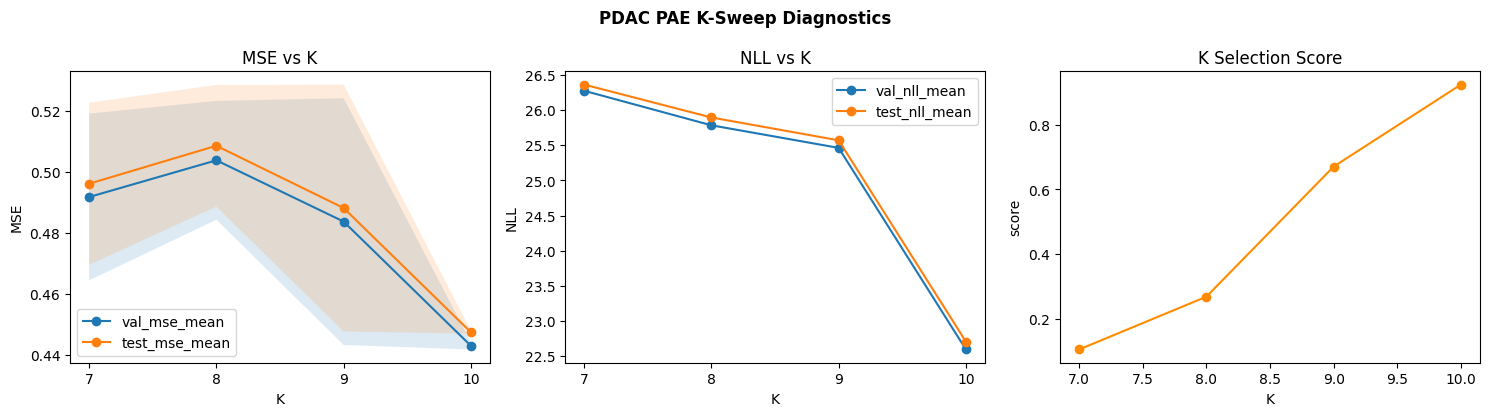

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Val/Test MSE across K
axes[0].plot(agg_df['k'], agg_df['val_mse_mean'], marker='o', label='val_mse_mean')
if 'val_mse_std' in agg_df.columns:
    y = agg_df['val_mse_mean'].to_numpy()
    e = agg_df['val_mse_std'].fillna(0).to_numpy()
    axes[0].fill_between(agg_df['k'], y-e, y+e, alpha=0.15)
axes[0].plot(agg_df['k'], agg_df['test_mse_mean'], marker='o', label='test_mse_mean')
if 'test_mse_std' in agg_df.columns:
    y = agg_df['test_mse_mean'].to_numpy()
    e = agg_df['test_mse_std'].fillna(0).to_numpy()
    axes[0].fill_between(agg_df['k'], y-e, y+e, alpha=0.15)
axes[0].set_title('MSE vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('MSE')
axes[0].legend()

# NLL across K
axes[1].plot(agg_df['k'], agg_df['val_nll_mean'], marker='o', label='val_nll_mean')
axes[1].plot(agg_df['k'], agg_df['test_nll_mean'], marker='o', label='test_nll_mean')
axes[1].set_title('NLL vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('NLL')
axes[1].legend()

# K-selection score
if 'k_selection_score' in ksel_df.columns:
    axes[2].plot(ksel_df['k'], ksel_df['k_selection_score'], marker='o', color='darkorange')
    axes[2].set_title('K Selection Score')
    axes[2].set_xlabel('K')
    axes[2].set_ylabel('score')
else:
    axes[2].text(0.5, 0.5, 'k_selection_score not found', ha='center', va='center')
    axes[2].set_axis_off()

for ax in axes[:2]:
    ax.set_xticks(sorted(agg_df['k'].unique()))

fig.suptitle('PDAC PAE K-Sweep Diagnostics', fontweight='bold')
fig.tight_layout()
plt.show()


## Step 6 - Recommended K and Best Seed


In [26]:

if 'recommended_k' in ksel_df.columns and not ksel_df.empty:
    recommended_k = int(ksel_df['recommended_k'].iloc[0])
else:
    # fallback: pick K with minimal val_mse_mean
    recommended_k = int(agg_df.loc[agg_df['val_mse_mean'].idxmin(), 'k'])

cand = seed_df[seed_df['k'] == recommended_k].copy()
if cand.empty:
    raise ValueError(f'No runs found for recommended_k={recommended_k}')

#recommended_k=8
best_seed = int(cand.loc[cand['val_mse'].idxmin(), 'seed'])
print('Recommended K:', recommended_k)
print('Best seed (min val_mse at recommended K):', best_seed)


Recommended K: 10
Best seed (min val_mse at recommended K): 123


## Step 7 - Inspect Archetype Marker Profiles (Recommended K)


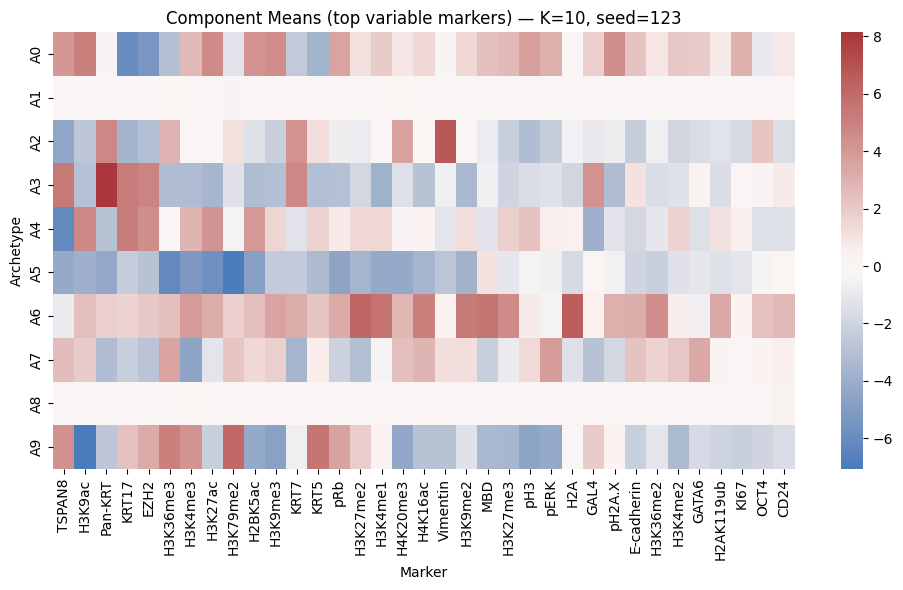

,CD11b,H2A,KRT5,H4K20me3,Pan-KRT,Vimentin,KRT7,CD24,pERK,H3K27me3,...,pH2A.X,H3K36me2,H4K16ac,H3K4me1,H3K9ac,CD44,KI67,H2BK5ac,H3K9me3,H3K4me2
A0,-1.076076,-0.126114,-3.707167,0.885636,-0.282990,-0.346732,-2.493472,0.810677,3.086705,2.697671,...,4.420245,0.911014,1.396866,1.922277,5.016283,-0.995968,3.028425,4.273562,4.550664,2.133612
A1,-0.006163,-0.013356,0.046432,0.155077,-0.015778,-0.051181,-0.051222,0.006297,-0.099970,-0.022658,...,-0.046201,-0.075429,0.003107,0.048406,0.068829,-0.149686,-0.053222,-0.004996,0.013555,-0.087477
A2,-0.690977,-0.620191,1.213231,3.670598,4.723211,6.725491,4.243690,-1.540574,-2.431212,-2.248214,...,-0.818040,-0.761513,0.122313,-0.074099,-2.671743,0.689654,-1.689256,-1.415173,-2.228357,-1.900890
A3,-0.550324,-1.912070,-3.104182,-1.374145,8.144413,-0.735942,4.722461,0.709130,-1.343007,-2.005327,...,-3.158969,-1.542466,-2.927526,-3.852699,-2.985650,-1.566547,0.102705,-3.187420,-3.046802,-1.355365
A4,-1.190930,0.388570,1.682313,0.203783,-2.956232,-1.185158,-1.216186,-1.404007,0.589805,1.750080,...,-1.201947,-1.118438,0.275250,1.464560,4.746786,1.401361,0.522904,4.006841,1.593548,1.626569
A5,0.323650,-1.672463,-3.277988,-4.230713,-4.364525,-2.695421,-2.443604,0.173421,-0.668549,-1.079673,...,-0.610938,-2.207098,-3.567789,-4.316850,-3.900081,-1.247162,-1.179298,-4.854102,-2.465515,-1.301457
A6,2.434062,6.533759,2.198655,2.754296,1.755952,0.316524,3.101693,2.714288,-0.462907,4.624083,...,3.059576,4.479059,5.042044,5.641134,2.455706,-0.488336,0.300225,2.484428,3.612384,0.602244
A7,1.289663,-1.345575,0.625897,2.482965,-3.161370,1.136876,-3.621783,0.502837,3.910876,-0.896129,...,-1.822803,1.714246,2.840661,-0.423191,2.020348,1.927074,-0.013580,1.455148,1.789188,2.101798
A8,-0.058613,-0.007946,0.019091,-0.038398,0.002499,0.005472,0.054186,0.330733,0.050255,-0.035271,...,-0.031556,-0.041971,0.081076,0.031607,-0.026065,0.074470,-0.166880,0.026122,0.088243,-0.007247
A9,-0.394066,-0.038291,5.534937,-4.428441,-2.673506,-2.937077,-0.712463,-1.541876,-4.291297,-3.536236,...,0.288524,-1.170114,-2.934256,0.323525,-7.068193,-1.370824,-2.230963,-4.309243,-4.787259,-3.280333


In [27]:
run_dir = OUTPUT_DIR / 'runs' / 'probabilistic_archetypal_ae' / f'dim_{recommended_k:02d}' / f'seed_{best_seed}'
if not run_dir.exists():
    # fallback for non-zero-padded dir names
    dim_matches = [p for p in (OUTPUT_DIR / 'runs' / 'probabilistic_archetypal_ae').glob('dim_*') if p.is_dir() and int(p.name.split('_')[-1]) == recommended_k]
    if not dim_matches:
        raise FileNotFoundError(f'Could not find run directory for K={recommended_k}')
    run_dir = dim_matches[0] / f'seed_{best_seed}'

cm = pd.read_csv(run_dir / 'component_means.csv', index_col=0)
cm.index = [f'A{i}' for i in range(cm.shape[0])]

# top variable markers for readability
top_markers = cm.var(axis=0).sort_values(ascending=False).head(35).index
mat = cm[top_markers]

fig, ax = plt.subplots(figsize=(max(10, mat.shape[1]*0.23), max(4, mat.shape[0]*0.6)))
sns.heatmap(mat, cmap='vlag', center=0.0, ax=ax)
ax.set_title(f'Component Means (top variable markers) — K={recommended_k}, seed={best_seed}')
ax.set_xlabel('Marker')
ax.set_ylabel('Archetype')
plt.tight_layout()
plt.show()

display(cm)


In [28]:
summary_out = OUTPUT_DIR / 'tables' / 'pdac_k_sweep_notebook_summary.csv'
out_df = agg_df.copy()
out_df['recommended_k'] = recommended_k
out_df.to_csv(summary_out, index=False)
print('Saved notebook summary:', summary_out)


Saved notebook summary: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDAC/pae_k_sweep/tables/pdac_k_sweep_notebook_summary.csv
